**Cell 1 — Imports and configuration**

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = os.getcwd()

THETA = 2
GRID_STEP = 0.02

**Cell 2 — Grid on (0,1]^2**

In [3]:
u = np.arange(GRID_STEP, 1.00, GRID_STEP)  # avoid 0 and 1: log(0) and log(1) undefined/zero
v = u
U, V = np.meshgrid(u, v)

**Cell 3 — Gumbel copula density function**

In [4]:
def gumbel_copula_density(U, V, theta):
    arg = (-np.log(U))**theta + (-np.log(V))**theta
    return (
        np.exp(-arg**(1/theta)) / (U * V)
        * (np.log(U) * np.log(V))**(theta - 1)
        * arg**(1/theta - 2)
        * (theta - 1 + arg**(1/theta))
    )

f = gumbel_copula_density(U, V, THETA)

**Cell 4 — 3D surface plot**

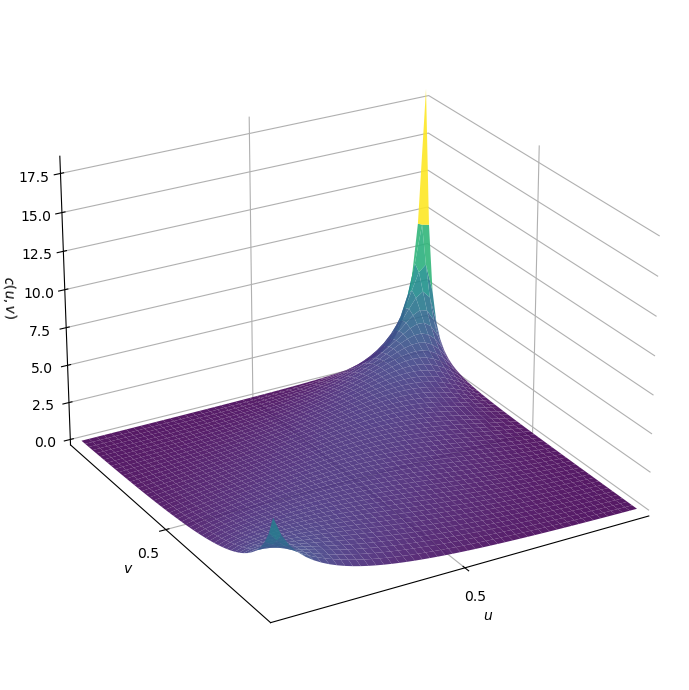

In [6]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(U, V, f, cmap="viridis", edgecolor="none", alpha=0.9)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("white")
ax.yaxis.pane.set_edgecolor("white")
ax.zaxis.pane.set_edgecolor("white")

ax.set_xlabel("$u$")
ax.set_ylabel("$v$")
ax.set_zlabel("$c(u,v)$")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([0.5])
ax.set_yticks([0.5])
ax.view_init(elev=25, azim=240)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "gumbel_copula_density.png"),
            dpi=200, transparent=True, bbox_inches="tight")
plt.show()